<a href="https://colab.research.google.com/github/Nilamsari01/Pengolahan_Citra_Digital/blob/main/NilamSariTugas5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# 1. IMPORT LIBRARY

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import os

from google.colab import files

In [58]:
# 3. MEMBACA CITRA

nama_file = "gambar5.jpg"

image = cv2.imread(nama_file)

if image is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca.")
    print("Ukuran gambar:", image.shape)

Gambar berhasil dibaca.
Ukuran gambar: (636, 450, 3)


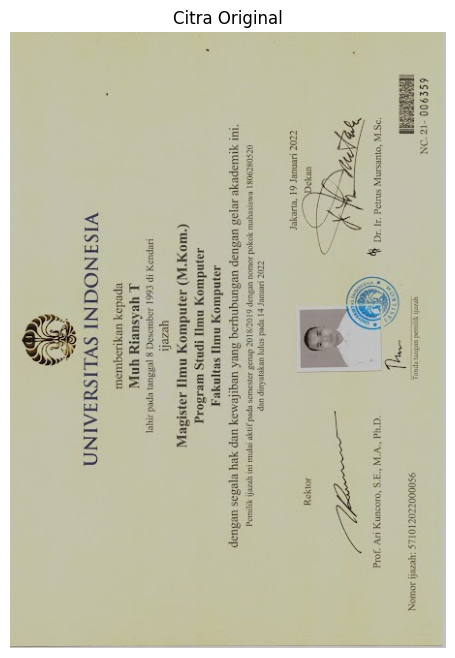

In [59]:
# 4. MENAMPILKAN CITRA ORIGINAL

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title("Citra Original")
plt.axis("off")
plt.show()

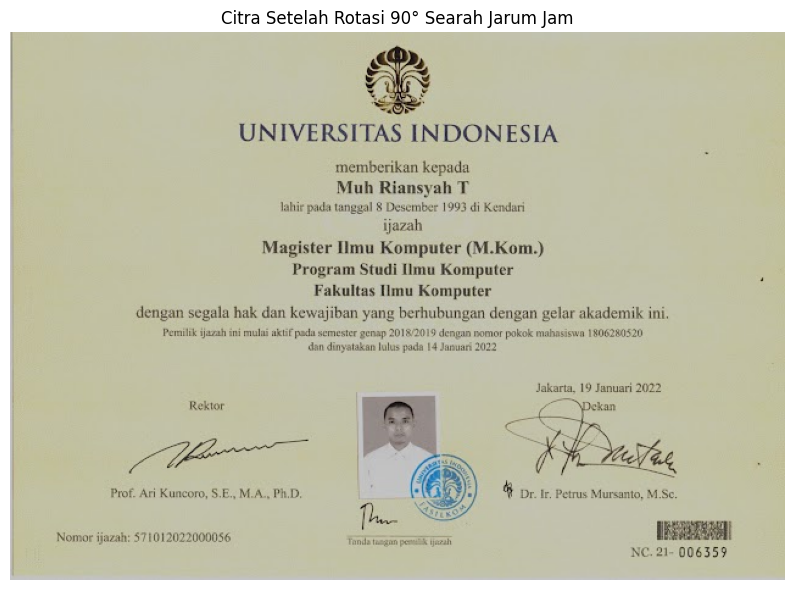

Ukuran setelah rotasi: (450, 636, 3)


In [60]:
# 5. ROTASI CITRA

rotated = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 12))
plt.imshow(rotated_rgb)
plt.title("Citra Setelah Rotasi 90° Searah Jarum Jam")
plt.axis("off")
plt.show()

print("Ukuran setelah rotasi:", rotated.shape)

In [61]:
crop = rotated[405:430, 100:200]

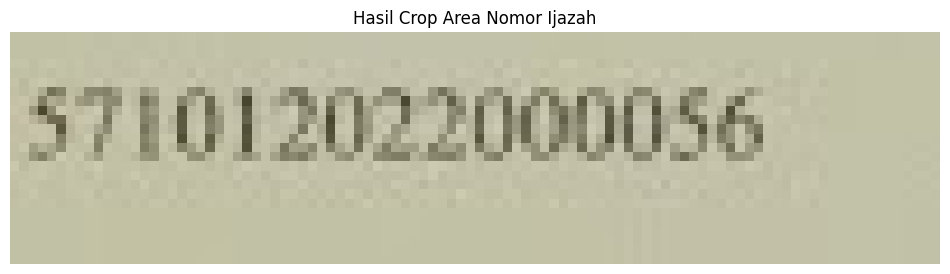

Ukuran crop: (25, 100, 3)


In [62]:
# 6. CROP AREA NOMOR IJAZAH

# SESUAIKAN KOORDINAT INI DENGAN POSISI NOMOR IJAZAH
y1 = 405
y2 = 430
x1 = 100
x2 = 200

crop = rotated[y1:y2, x1:x2]

crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.imshow(crop_rgb)
plt.title("Hasil Crop Area Nomor Ijazah")
plt.axis("off")
plt.show()

print("Ukuran crop:", crop.shape)

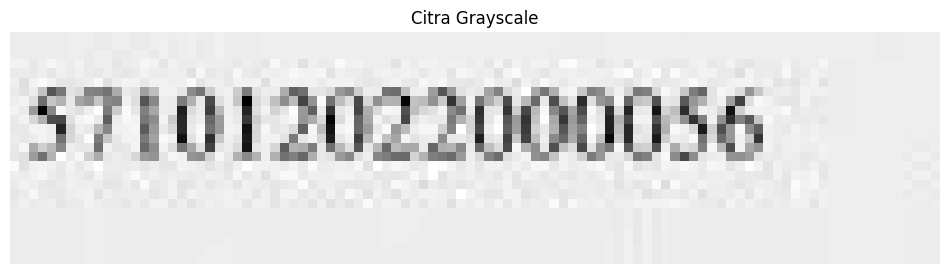

Ukuran grayscale: (25, 100)


In [63]:
# 7. KONVERSI CROP KE GRAYSCALE


gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))
plt.imshow(gray, cmap="gray")
plt.title("Citra Grayscale")
plt.axis("off")
plt.show()

print("Ukuran grayscale:", gray.shape)

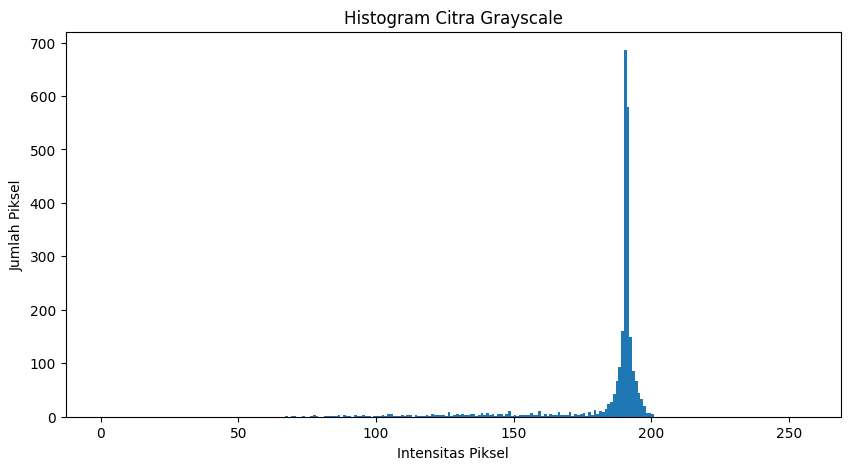

In [64]:
# 8. HISTOGRAM CITRA GRAYSCALE

plt.figure(figsize=(10, 5))

plt.hist(
    gray.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram Citra Grayscale")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.show()

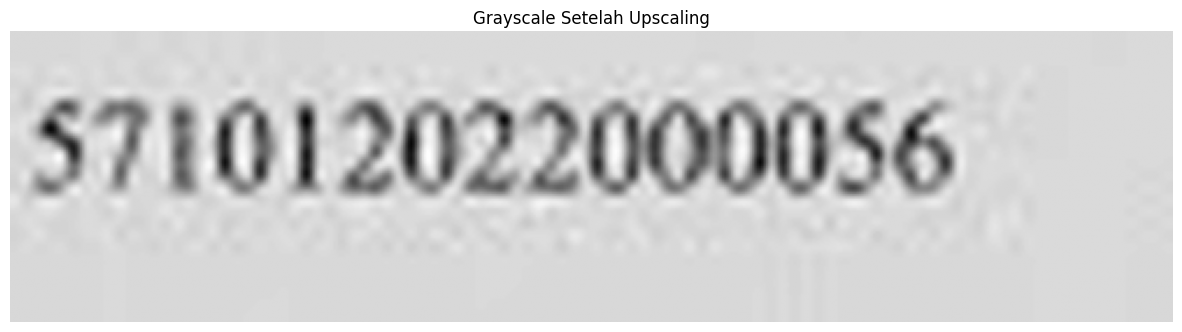

Ukuran sebelum upscaling : (25, 100)
Ukuran setelah upscaling : (125, 500)


In [65]:
# 9. UPSCALING CITRA

scale = 5

gray_ocr = cv2.resize(
    gray,
    None,
    fx=scale,
    fy=scale,
    interpolation=cv2.INTER_CUBIC
)

plt.figure(figsize=(15, 5))
plt.imshow(gray_ocr, cmap="gray")
plt.title("Grayscale Setelah Upscaling")
plt.axis("off")
plt.show()

print("Ukuran sebelum upscaling :", gray.shape)
print("Ukuran setelah upscaling :", gray_ocr.shape)

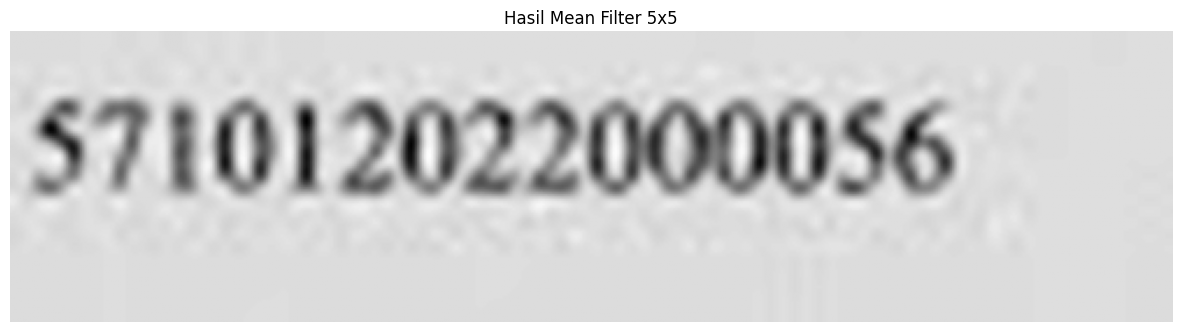

In [66]:
# 10. MEAN FILTER

mean_filtered = cv2.blur(
    gray_ocr,
    (5, 5)
)

plt.figure(figsize=(15, 5))
plt.imshow(mean_filtered, cmap="gray")
plt.title("Hasil Mean Filter 5x5")
plt.axis("off")
plt.show()

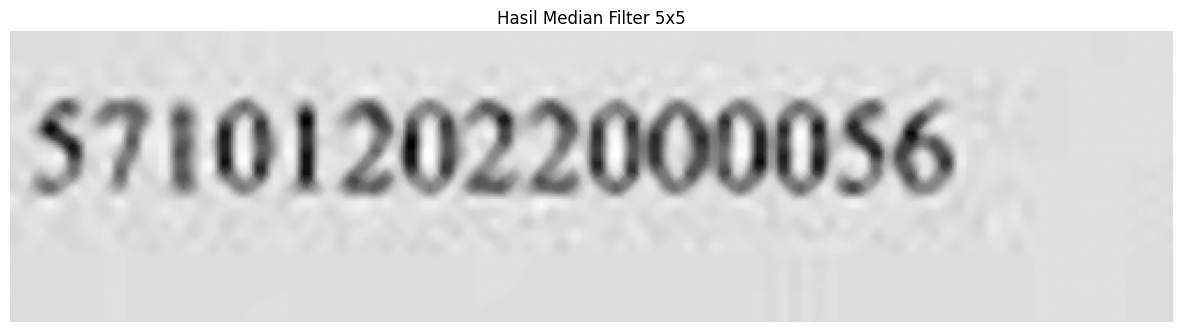

In [67]:
# 11. MEDIAN FILTER

median_filtered = cv2.medianBlur(
    gray_ocr,
    5
)

plt.figure(figsize=(15, 5))
plt.imshow(median_filtered, cmap="gray")
plt.title("Hasil Median Filter 5x5")
plt.axis("off")
plt.show()

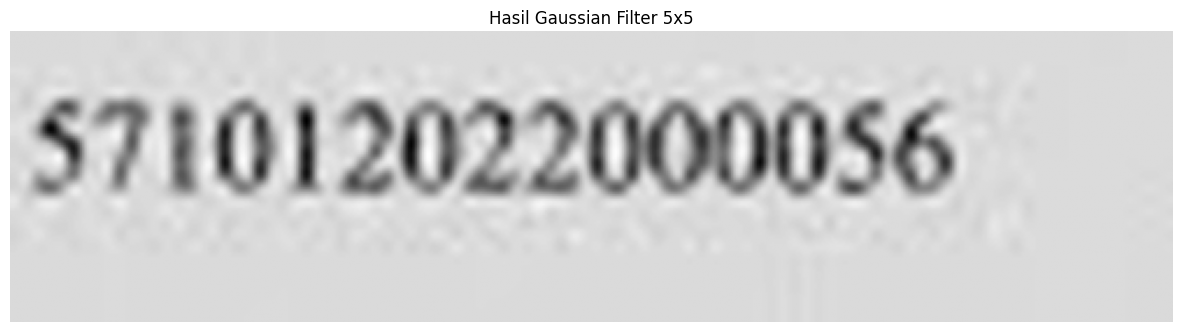

In [68]:
# 12. GAUSSIAN FILTER

gaussian_filtered = cv2.GaussianBlur(
    gray_ocr,
    (5, 5),
    0
)

plt.figure(figsize=(15, 5))
plt.imshow(gaussian_filtered, cmap="gray")
plt.title("Hasil Gaussian Filter 5x5")
plt.axis("off")
plt.show()

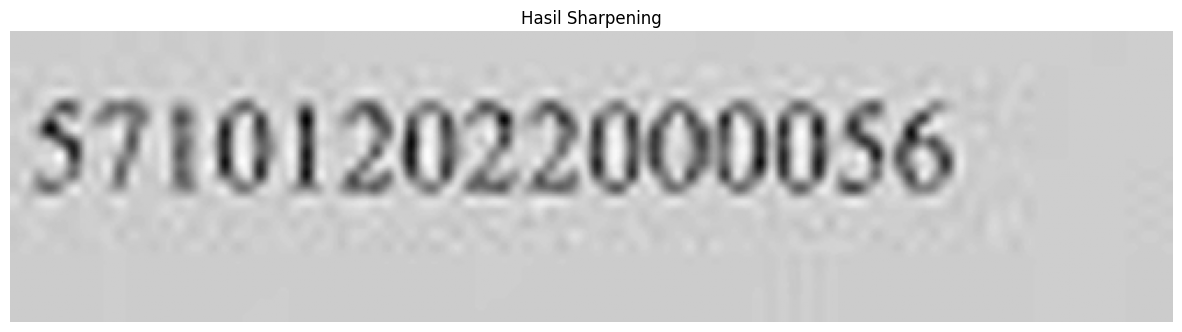

In [69]:
# 13. SHARPENING
blur_for_sharpening = cv2.GaussianBlur(
    gray_ocr,
    (0, 0),
    3
)

sharpened = cv2.addWeighted(
    gray_ocr,
    1.5,
    blur_for_sharpening,
    -0.5,
    0
)

plt.figure(figsize=(15, 5))
plt.imshow(sharpened, cmap="gray")
plt.title("Hasil Sharpening")
plt.axis("off")
plt.show()

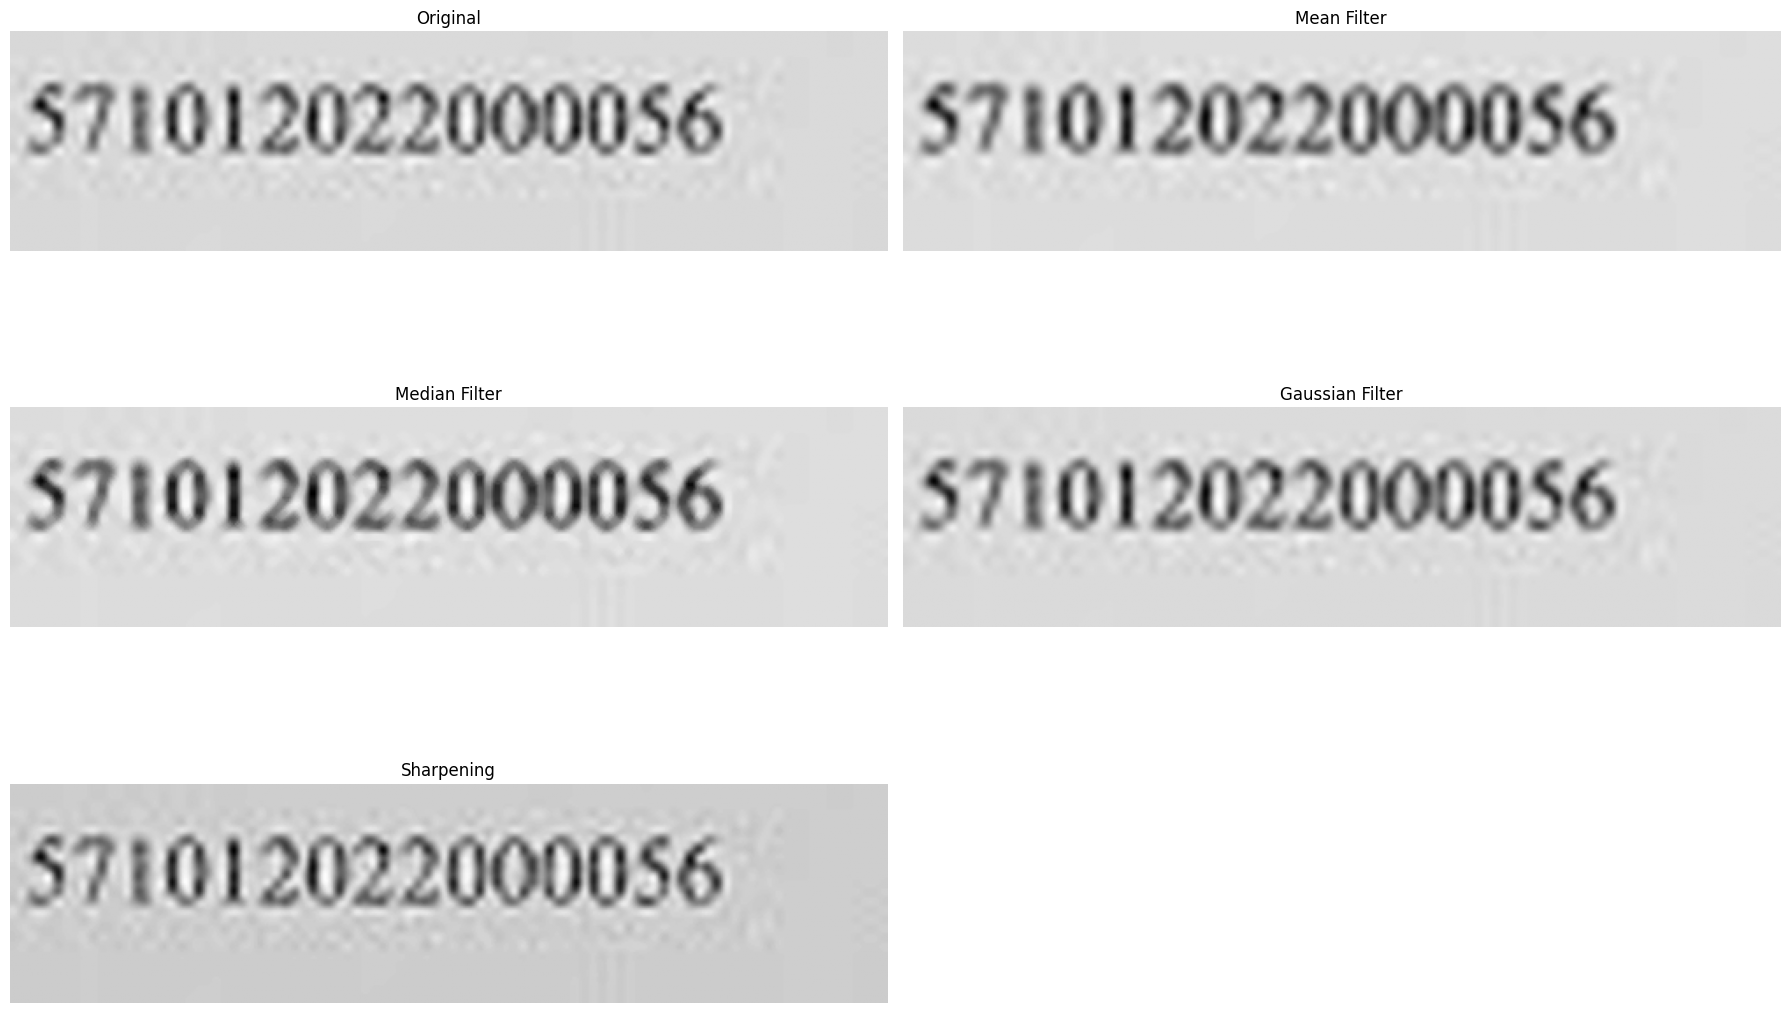

In [70]:
# 14. PERBANDINGAN SEMUA METODE

hasil_filter = {
    "Original": gray_ocr,
    "Mean Filter": mean_filtered,
    "Median Filter": median_filtered,
    "Gaussian Filter": gaussian_filtered,
    "Sharpening": sharpened
}

plt.figure(figsize=(18, 12))

for i, (nama, hasil) in enumerate(hasil_filter.items(), 1):

    plt.subplot(3, 2, i)

    plt.imshow(hasil, cmap="gray")
    plt.title(nama)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
# 15. MENYIMPAN HASIL FILTER

cv2.imwrite("original.png", gray_ocr)
cv2.imwrite("mean_filter.png", mean_filtered)
cv2.imwrite("median_filter.png", median_filtered)
cv2.imwrite("gaussian_filter.png", gaussian_filtered)
cv2.imwrite("sharpening.png", sharpened)

print("Semua hasil filtering berhasil disimpan.")

Semua hasil filtering berhasil disimpan.


In [72]:
# 16. INSTALL TESSERACT OCR

!apt-get update -qq
!apt-get install -y tesseract-ocr -qq
!pip install pytesseract -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [73]:
# 17. IMPORT PYTESSERACT

import pytesseract

print("Tesseract berhasil dipasang.")
print(pytesseract.get_tesseract_version())

Tesseract berhasil dipasang.
5.3.4


In [74]:
# 18. FUNGSI OCR

def lakukan_ocr(image):

    hasil = pytesseract.image_to_string(
        image,
        config="--psm 7"
    )

    return hasil

In [75]:
# 19. MEMBERSIHKAN HASIL OCR

def bersihkan_ocr(teks):

    teks = teks.upper()

    # Menghapus spasi
    teks = teks.replace(" ", "")

    # Menghapus baris baru
    teks = teks.replace("\n", "")

    # Hanya mempertahankan huruf dan angka
    teks = re.sub(
        r"[^A-Z0-9]",
        "",
        teks
    )

    return teks

In [76]:
# 20. OCR SEMUA METODE

hasil_ocr = {}

for nama, gambar in hasil_filter.items():

    teks = lakukan_ocr(gambar)

    teks_bersih = bersihkan_ocr(teks)

    hasil_ocr[nama] = teks_bersih

    print("----------------------------------------")
    print("Metode :", nama)
    print("OCR    :", teks_bersih)

print("----------------------------------------")

----------------------------------------
Metode : Original
OCR    : 571012022000056
----------------------------------------
Metode : Mean Filter
OCR    : 571012022000056
----------------------------------------
Metode : Median Filter
OCR    : 571012022000056
----------------------------------------
Metode : Gaussian Filter
OCR    : 571012022000056
----------------------------------------
Metode : Sharpening
OCR    : 571012022000056
----------------------------------------


In [77]:
# 21. GROUND TRUTH / NOMOR IJAZAH ASLI

nomor_benar = "571012022000056"

nomor_benar = bersihkan_ocr(nomor_benar)

print("Nomor ijazah sebenarnya :", nomor_benar)
print("Jumlah karakter         :", len(nomor_benar))

Nomor ijazah sebenarnya : 571012022000056
Jumlah karakter         : 15


In [78]:
# 22. FUNGSI PERHITUNGAN AKURASI

def hitung_akurasi(hasil, ground_truth):

    jumlah_benar = 0

    panjang = min(
        len(hasil),
        len(ground_truth)
    )

    for i in range(panjang):

        if hasil[i] == ground_truth[i]:
            jumlah_benar += 1

    if len(ground_truth) > 0:

        akurasi = (
            jumlah_benar /
            len(ground_truth)
        ) * 100

    else:

        akurasi = 0

    return jumlah_benar, akurasi

In [79]:
# 23. PERHITUNGAN AKURASI OCR

data_hasil = []

for metode, hasil in hasil_ocr.items():

    karakter_benar, akurasi = hitung_akurasi(
        hasil,
        nomor_benar
    )

    data_hasil.append([
        metode,
        hasil,
        karakter_benar,
        round(akurasi, 2)
    ])

In [80]:
# 24. TABEL HASIL OCR

df_hasil = pd.DataFrame(
    data_hasil,
    columns=[
        "Metode",
        "Hasil OCR",
        "Karakter Benar",
        "Akurasi (%)"
    ]
)

df_hasil

,Metode,Hasil OCR,Karakter Benar,Akurasi (%)
0,Original,571012022000056,15,100.0
1,Mean Filter,571012022000056,15,100.0
2,Median Filter,571012022000056,15,100.0
3,Gaussian Filter,571012022000056,15,100.0
4,Sharpening,571012022000056,15,100.0


In [81]:
# 25. TABEL HASIL YANG LEBIH RAPI

display(
    df_hasil.style
    .format({
        "Akurasi (%)": "{:.2f}"
    })
)

,Metode,Hasil OCR,Karakter Benar,Akurasi (%)
0,Original,571012022000056,15,100.00
1,Mean Filter,571012022000056,15,100.00
2,Median Filter,571012022000056,15,100.00
3,Gaussian Filter,571012022000056,15,100.00
4,Sharpening,571012022000056,15,100.00


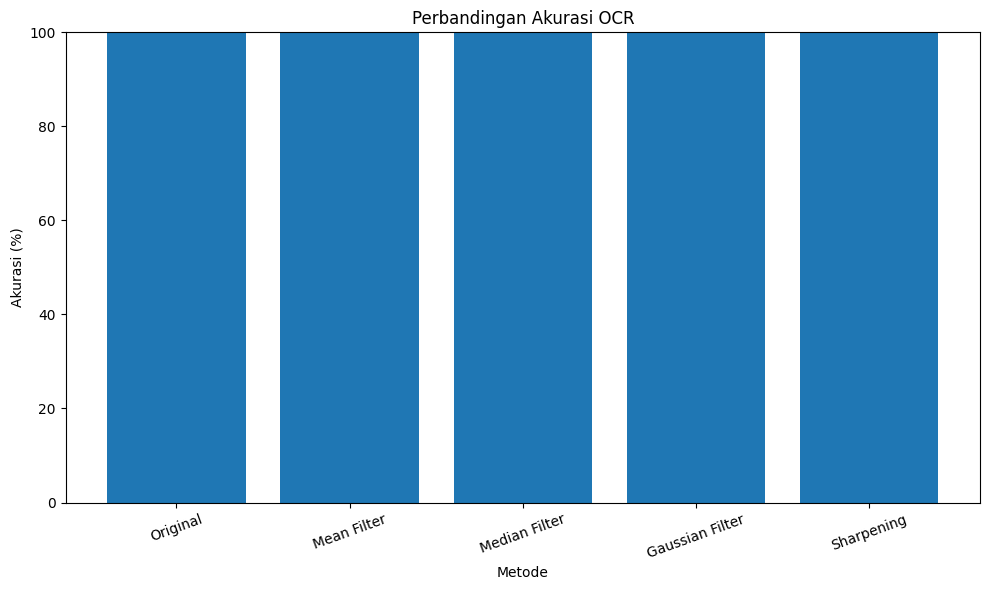

In [82]:
# 26. GRAFIK PERBANDINGAN AKURASI

plt.figure(figsize=(10, 6))

plt.bar(
    df_hasil["Metode"],
    df_hasil["Akurasi (%)"]
)

plt.title("Perbandingan Akurasi OCR")
plt.xlabel("Metode")
plt.ylabel("Akurasi (%)")

plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [83]:
# 27. SIMPAN HASIL KE CSV

df_hasil.to_csv(
    "hasil_ocr_filtering.csv",
    index=False
)

print("Tabel berhasil disimpan sebagai hasil_ocr_filtering.csv")

Tabel berhasil disimpan sebagai hasil_ocr_filtering.csv


In [84]:
# 28. RINGKASAN HASIL

print("==========================================")
print("RINGKASAN HASIL OCR")
print("==========================================")

for index, row in df_hasil.iterrows():

    print(
        f"{row['Metode']:<20} | "
        f"OCR: {row['Hasil OCR']:<20} | "
        f"Karakter Benar: {row['Karakter Benar']} | "
        f"Akurasi: {row['Akurasi (%)']}%"
    )

RINGKASAN HASIL OCR
Original             | OCR: 571012022000056      | Karakter Benar: 15 | Akurasi: 100.0%
Mean Filter          | OCR: 571012022000056      | Karakter Benar: 15 | Akurasi: 100.0%
Median Filter        | OCR: 571012022000056      | Karakter Benar: 15 | Akurasi: 100.0%
Gaussian Filter      | OCR: 571012022000056      | Karakter Benar: 15 | Akurasi: 100.0%
Sharpening           | OCR: 571012022000056      | Karakter Benar: 15 | Akurasi: 100.0%
